In [1]:
print("Hello")

Hello


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as image
import glob
import os

In [4]:
images_fp = './images'

In [5]:
image_names = [os.path.basename(file) for file in glob.glob(os.path.join(images_fp, '*.jpg'))]

In [19]:
unique_labels = sorted(set(
    [' '.join(name.split('_')[:-1]) for name in image_names]
))

label_to_id = {label: idx for idx, label in enumerate(unique_labels)}

print("Number of breeds:", len(unique_labels))

Number of breeds: 37


In [6]:
len(image_names)

7390

In [7]:
labels = [' '.join(name.split('_')[:-1:]) for name in image_names]

In [8]:
labels

['Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssinian',
 'Abyssini

In [10]:
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array

^C


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.0 which is incompatible.


  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.35.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.81.0-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
  Using cached keras-3.14.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cach

In [20]:
features = []
labels = []

IMAGE_SIZE = (224, 224)

for i, name in enumerate(image_names):

    label = ' '.join(name.split('_')[:-1])

    label_encoded = label_to_id[label]

    img = load_img(os.path.join(images_fp, name))

    img = tf.image.resize_with_pad(
        img_to_array(img, dtype='uint8'),
        *IMAGE_SIZE
    ).numpy().astype('uint8')

    features.append(img)
    labels.append(label_encoded)

    if i % 500 == 0:
        print(f"Processed {i}/{len(image_names)}")

print("Done")

Processed 0/7390
Processed 500/7390
Processed 1000/7390
Processed 1500/7390
Processed 2000/7390
Processed 2500/7390
Processed 3000/7390
Processed 3500/7390
Processed 4000/7390
Processed 4500/7390
Processed 5000/7390
Processed 5500/7390
Processed 6000/7390
Processed 6500/7390
Processed 7000/7390
Done


In [21]:
print(len(features))
print(len(labels))

7390
7390


In [22]:
features

[array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]], shape=(224, 224, 3), dtype=uint8),
 array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0,

In [23]:
labels

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,
 12,


In [24]:
features_array = np.array(features)
labels_array = np.array(labels)

In [25]:
labels_one_hot = pd.get_dummies(labels_array)

In [26]:
labels_one_hot

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7385,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7386,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7387,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7388,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [27]:
from sklearn.model_selection import train_test_split


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    features_array,
    labels_one_hot.values,
    test_size=0.2,
    random_state=42
)

In [33]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=1
)

In [34]:
from tensorflow.keras import layers, Input, Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as pp_i
from tensorflow.keras.layers import RandomFlip, RandomRotation, Dense, Dropout
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

In [36]:
data_augmentation = Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.2)
])

prediction_layer = Dense(37, activation='softmax')

In [37]:
resnet_model = ResNet50(
    include_top=False,
    pooling='avg',
    weights='imagenet'
)

resnet_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 24s 0us/step


In [38]:
# Build Model

inputs = Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = pp_i(x)
x = resnet_model(x, training=False)
x = Dropout(0.2)(x)

outputs = prediction_layer(x)

model = Model(inputs, outputs)

In [39]:
model.compile(optimizer=Adam(), loss=CategoricalCrossentropy(), metrics=['accuracy'])

In [40]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10
)

Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 768s 5s/step - accuracy: 0.4558 - loss: 1.9766 - val_accuracy: 0.8410 - val_loss: 0.5700
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 745s 5s/step - accuracy: 0.7134 - loss: 0.9205 - val_accuracy: 0.8681 - val_loss: 0.4309
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 664s 5s/step - accuracy: 0.7643 - loss: 0.7566 - val_accuracy: 0.8877 - val_loss: 0.3671
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 683s 5s/step - accuracy: 0.7866 - loss: 0.6559 - val_accuracy: 0.8877 - val_loss: 0.3609
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 1036s 7s/step - accuracy: 0.8133 - loss: 0.5932 - val_accuracy: 0.8667 - val_loss: 0.4003
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 824s 6s/step - accuracy: 0.8309 - loss: 0.5228 - val_accuracy: 0.8843 - val_loss: 0.3617
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 689s 5s/step - accuracy: 0.8381 - loss: 0.4979 - val_accuracy: 0.8769 - val_loss: 0.3950
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 779s 5s/step - accuracy: 0.8403 - loss: 0.4963 - val_acc

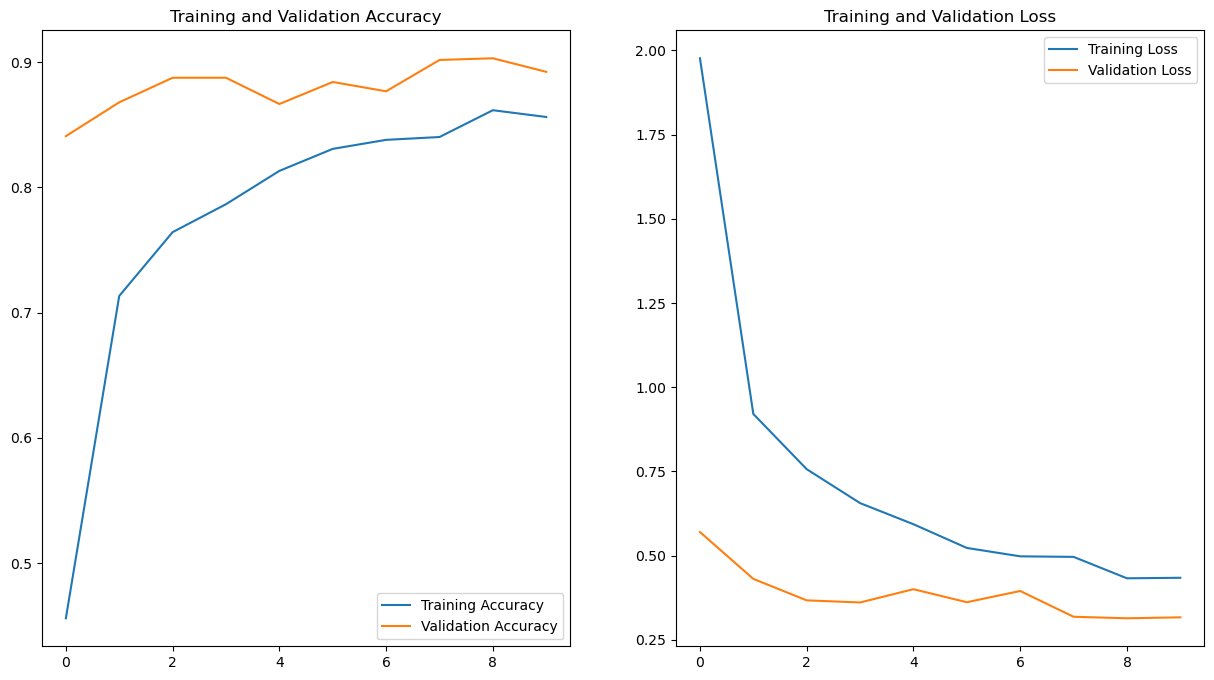

In [41]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [42]:
model.evaluate(X_test, y_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 279s 6s/step - accuracy: 0.8843 - loss: 0.3340


[0.3340424597263336, 0.884303092956543]

In [43]:
y_pred = model.predict(X_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 309s 6s/step
